# LT-CCD Data Preparation for Coherence Stacks

This notebook prepares Sentinel-1 coherence rasters for LT-CCD damage analysis.

## Goal
The notebook:
- scans post-event and baseline folders recursively
- finds all coherence rasters (`*_corr.tif`)
- loads the AOI
- selects a reference raster grid
- reprojects all rasters to the same CRS, resolution, extent, and transform
- clips all rasters to the AOI
- saves standardized rasters into separate `post` and `baseline` output folders
- exports raster inventory and processing summary

## Input
- Post-event coherence folder
- Baseline coherence folder
- AOI vector file

## Output
- Prepared post-event coherence rasters
- Prepared baseline coherence rasters
- Inventory CSV
- Processing summary JSON

## Notes
This notebook performs data preparation only.
No LT-CCD statistics or damage detection are computed here.

In [1]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
from shapely.geometry import mapping
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# =========================
# INPUT PATHS
# =========================
post_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/SLC_1/08042026_Teheran_Post")
baseline_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/SLC_1/20032025_Teheran_Baseline")
aoi_path = Path("/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/Teheran_AOI/Teheran_AOI.geojson")

# =========================
# OUTPUT ROOT
# =========================
output_root = Path("/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026")
prepared_post_dir = output_root / "prepared" / "post"
prepared_baseline_dir = output_root / "prepared" / "baseline"
metadata_dir = output_root / "metadata"
preview_dir = output_root / "preview"

prepared_post_dir.mkdir(parents=True, exist_ok=True)
prepared_baseline_dir.mkdir(parents=True, exist_ok=True)
metadata_dir.mkdir(parents=True, exist_ok=True)
preview_dir.mkdir(parents=True, exist_ok=True)

# =========================
# PROCESSING SETTINGS
# =========================
corr_suffix = "_corr.tif"
nodata_value = np.nan
resampling_method = Resampling.bilinear
reference_source = "post"   # options: "post", "baseline"
reference_index = 0         # which raster from the chosen source will define the target grid

print("📋 Configuration loaded:")
print(f"   Post folder: {post_dir}")
print(f"   Baseline folder: {baseline_dir}")
print(f"   AOI path: {aoi_path}")
print(f"   Output root: {output_root}")
print(f"   Raster suffix filter: {corr_suffix}")
print(f"   Reference source: {reference_source}")
print(f"   Reference index: {reference_index}")

📋 Configuration loaded:
   Post folder: /Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/SLC_1/08042026_Teheran_Post
   Baseline folder: /Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/SLC_1/20032025_Teheran_Baseline
   AOI path: /Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/Teheran_AOI/Teheran_AOI.geojson
   Output root: /Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026
   Raster suffix filter: _corr.tif
   Reference source: post
   Reference index: 0


In [3]:
def find_coherence_rasters(folder: Path, suffix: str = "_corr.tif") -> list[Path]:
    """Recursively find valid coherence rasters and ignore hidden/system files."""
    rasters = []
    
    for p in folder.rglob(f"*{suffix}"):
        if not p.is_file():
            continue
        
        # Skip if any part of the path is hidden/system-like
        if any(part.startswith(".") for part in p.parts):
            continue
        
        rasters.append(p)
    
    return sorted(rasters)


def load_aoi(aoi_file: Path) -> gpd.GeoDataFrame:
    """Load AOI and dissolve into a single geometry if needed."""
    gdf = gpd.read_file(aoi_file)
    if gdf.empty:
        raise ValueError(f"AOI file is empty: {aoi_file}")
    if len(gdf) > 1:
        gdf = gdf.dissolve().reset_index(drop=True)
    return gdf


def get_raster_info(raster_path: Path) -> dict:
    """Read basic raster metadata."""
    with rasterio.open(raster_path) as src:
        return {
            "path": str(raster_path),
            "name": raster_path.name,
            "crs": str(src.crs),
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
            "bounds": tuple(src.bounds),
            "res_x": src.transform.a,
            "res_y": src.transform.e,
            "transform": tuple(src.transform),
        }


def choose_reference_raster(post_files: list[Path], baseline_files: list[Path], source: str = "post", index: int = 0) -> Path:
    """Select reference raster for target grid."""
    if source == "post":
        candidates = post_files
    elif source == "baseline":
        candidates = baseline_files
    else:
        raise ValueError("reference_source must be either 'post' or 'baseline'")
    
    if len(candidates) == 0:
        raise ValueError(f"No files available in reference source: {source}")
    
    if index >= len(candidates):
        raise IndexError(f"reference_index={index} is out of range for {source} files")
    
    return candidates[index]


def clip_bounds_to_aoi(reference_raster_path: Path, aoi_gdf: gpd.GeoDataFrame):
    """Compute AOI bounds in reference raster CRS."""
    with rasterio.open(reference_raster_path) as src:
        aoi_in_ref = aoi_gdf.to_crs(src.crs)
        bounds = aoi_in_ref.total_bounds
        return src.crs, aoi_in_ref, bounds


def build_target_grid_from_reference(reference_raster_path: Path, aoi_gdf: gpd.GeoDataFrame):
    """
    Build target grid from the reference raster and AOI.
    The output grid uses:
    - reference CRS
    - reference resolution
    - AOI-clipped extent
    """
    with rasterio.open(reference_raster_path) as src:
        aoi_in_ref = aoi_gdf.to_crs(src.crs)
        geoms = [mapping(geom) for geom in aoi_in_ref.geometry]
        
        clipped_data, clipped_transform = mask(
            src,
            geoms,
            crop=True,
            nodata=src.nodata if src.nodata is not None else np.nan
        )
        
        target_profile = src.profile.copy()
        target_profile.update({
            "height": clipped_data.shape[1],
            "width": clipped_data.shape[2],
            "transform": clipped_transform,
            "crs": src.crs,
            "count": 1,
            "dtype": "float32",
            "nodata": np.nan,
            "compress": "lzw"
        })
        
    return target_profile, aoi_in_ref


def prepare_single_raster(
    input_path: Path,
    output_path: Path,
    aoi_gdf: gpd.GeoDataFrame,
    target_profile: dict,
    resampling: Resampling = Resampling.bilinear
) -> dict:
    """
    Reproject raster to target grid and clip implicitly by the target grid.
    """
    with rasterio.open(input_path) as src:
        src_array = src.read(1).astype("float32")
        
        # Convert input nodata to NaN if needed
        if src.nodata is not None:
            src_array = np.where(src_array == src.nodata, np.nan, src_array)

        dst_array = np.full(
            (target_profile["height"], target_profile["width"]),
            np.nan,
            dtype="float32"
        )

        reproject(
            source=src_array,
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=np.nan,
            dst_transform=target_profile["transform"],
            dst_crs=target_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling
        )

        valid_pixels = int(np.sum(~np.isnan(dst_array)))
        total_pixels = int(dst_array.size)

        output_profile = target_profile.copy()
        output_profile.update({
            "driver": "GTiff",
            "count": 1,
            "dtype": "float32",
            "nodata": np.nan,
            "compress": "lzw"
        })

        with rasterio.open(output_path, "w", **output_profile) as dst:
            dst.write(dst_array, 1)

    return {
        "input_name": input_path.name,
        "output_name": output_path.name,
        "input_path": str(input_path),
        "output_path": str(output_path),
        "valid_pixels": valid_pixels,
        "total_pixels": total_pixels,
        "valid_percent": round(valid_pixels / total_pixels * 100, 2) if total_pixels > 0 else 0.0,
    }


def make_output_name(input_path: Path, prefix: str) -> str:
    """Create standardized output filename."""
    stem = input_path.stem
    return f"{prefix}_{stem}.tif"


def preview_raster(raster_path: Path, aoi_gdf: gpd.GeoDataFrame, title: str):
    """Quick raster preview."""
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype("float32")
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

        aoi_plot = aoi_gdf.to_crs(src.crs)

        fig, ax = plt.subplots(figsize=(8, 8))
        im = ax.imshow(arr, cmap="viridis", vmin=0, vmax=1, extent=extent)
        aoi_plot.boundary.plot(ax=ax, color="red", linewidth=1.5)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        plt.colorbar(im, ax=ax, shrink=0.7, label="Coherence")
        plt.tight_layout()
        plt.show()

def filter_valid_tifs(file_list):
    """Remove macOS system files and invalid tif files."""
    valid = []
    skipped = []
    
    for p in file_list:
        name = p.name
        
        if name.startswith("._") or name.startswith(".") or name == ".DS_Store":
            skipped.append(name)
            continue
        
        valid.append(p)
    
    return sorted(valid), skipped

In [4]:
print("🔎 Scanning input folders for coherence rasters...")

post_files = find_coherence_rasters(post_dir, corr_suffix)
baseline_files = find_coherence_rasters(baseline_dir, corr_suffix)

print(f"   ✅ Post rasters found: {len(post_files)}")
for p in post_files[:5]:
    print(f"      - {p.name}")
if len(post_files) > 5:
    print("      ...")

print(f"\n   ✅ Baseline rasters found: {len(baseline_files)}")
for p in baseline_files[:5]:
    print(f"      - {p.name}")
if len(baseline_files) > 5:
    print("      ...")

if len(post_files) == 0:
    raise ValueError(f"No coherence rasters found in post folder: {post_dir}")
if len(baseline_files) == 0:
    raise ValueError(f"No coherence rasters found in baseline folder: {baseline_dir}")

🔎 Scanning input folders for coherence rasters...
   ✅ Post rasters found: 25
      - S1AA_20250212T023717_20260408T023707_VVR420_INT40_G_ueF_3546_corr.tif
      - S1AA_20250224T023717_20260408T023707_VVR408_INT40_G_ueF_08BC_corr.tif
      - S1AA_20250308T023717_20260408T023707_VVR396_INT40_G_ueF_061D_corr.tif
      - S1AA_20250320T023719_20260408T023707_VVR384_INT40_G_ueF_F4A1_corr.tif
      - S1AA_20250401T023718_20260408T023707_VVR372_INT40_G_ueF_2323_corr.tif
      ...

   ✅ Baseline rasters found: 24
      - S1AA_20240206T023724_20250320T023719_VVP408_INT40_G_ueF_6CA2_corr.tif
      - S1AA_20240218T023724_20250320T023719_VVP396_INT40_G_ueF_05EA_corr.tif
      - S1AA_20240301T023724_20250320T023719_VVP384_INT40_G_ueF_91D1_corr.tif
      - S1AA_20240313T023724_20250320T023719_VVP372_INT40_G_ueF_C022_corr.tif
      - S1AA_20240325T023724_20250320T023719_VVP360_INT40_G_ueF_77CD_corr.tif
      ...


In [5]:
print("🗺️ Loading AOI...")

aoi_gdf = load_aoi(aoi_path)

print(f"   ✅ AOI loaded successfully")
print(f"   Features: {len(aoi_gdf)}")
print(f"   CRS: {aoi_gdf.crs}")
print(f"   Bounds: {aoi_gdf.total_bounds}")

🗺️ Loading AOI...
   ✅ AOI loaded successfully
   Features: 1
   CRS: EPSG:4326
   Bounds: [51.16473555 35.60008291 51.6357342  35.83222285]


In [6]:
print("📂 Reading raster metadata...")

post_inventory = pd.DataFrame([get_raster_info(p) for p in post_files])
post_inventory["group"] = "post"

baseline_inventory = pd.DataFrame([get_raster_info(p) for p in baseline_files])
baseline_inventory["group"] = "baseline"

inventory = pd.concat([post_inventory, baseline_inventory], ignore_index=True)

print(f"   ✅ Inventory created with {len(inventory)} rasters")
display(inventory[["group", "name", "crs", "width", "height", "dtype"]].head(10))

📂 Reading raster metadata...
   ✅ Inventory created with 49 rasters


,group,name,crs,width,height,dtype
0,post,S1AA_20250212T023717_20260408T023707_VVR420_IN...,EPSG:32639,7279,5805,float32
1,post,S1AA_20250224T023717_20260408T023707_VVR408_IN...,EPSG:32639,7277,5801,float32
2,post,S1AA_20250308T023717_20260408T023707_VVR396_IN...,EPSG:32639,7281,5805,float32
3,post,S1AA_20250320T023719_20260408T023707_VVR384_IN...,EPSG:32639,7269,5647,float32
4,post,S1AA_20250401T023718_20260408T023707_VVR372_IN...,EPSG:32639,7277,5803,float32
5,post,S1AA_20250413T023718_20260408T023707_VVR360_IN...,EPSG:32639,7279,5805,float32
6,post,S1AA_20250425T023718_20260408T023707_VVR348_IN...,EPSG:32639,7279,5801,float32
7,post,S1AA_20250507T023718_20260408T023707_VVR336_IN...,EPSG:32639,7279,5803,float32
8,post,S1AA_20250519T023718_20260408T023707_VVR324_IN...,EPSG:32639,7277,5801,float32
9,post,S1AA_20250718T023715_20260408T023707_VVR264_IN...,EPSG:32639,7279,5801,float32


In [7]:
print("🎯 Selecting reference raster...")

reference_raster = choose_reference_raster(
    post_files=post_files,
    baseline_files=baseline_files,
    source=reference_source,
    index=reference_index
)

print(f"   ✅ Reference raster selected: {reference_raster.name}")

target_profile, aoi_in_target_crs = build_target_grid_from_reference(reference_raster, aoi_gdf)

print("\n📊 Target grid:")
print(f"   CRS: {target_profile['crs']}")
print(f"   Width: {target_profile['width']}")
print(f"   Height: {target_profile['height']}")
print(f"   Transform: {target_profile['transform']}")
print(f"   Resolution X: {target_profile['transform'].a}")
print(f"   Resolution Y: {target_profile['transform'].e}")

target_bounds = array_bounds(
    target_profile["height"],
    target_profile["width"],
    target_profile["transform"]
)

print(f"   Bounds: {target_bounds}")

🎯 Selecting reference raster...
   ✅ Reference raster selected: S1AA_20250212T023717_20260408T023707_VVR420_INT40_G_ueF_3546_corr.tif

📊 Target grid:
   CRS: EPSG:32639
   Width: 1069
   Height: 649
   Transform: | 40.00, 0.00, 514860.00|
| 0.00,-40.00, 3965540.00|
| 0.00, 0.00, 1.00|
   Resolution X: 40.0
   Resolution Y: -40.0
   Bounds: (514860.0, 3939580.0, 557620.0, 3965540.0)


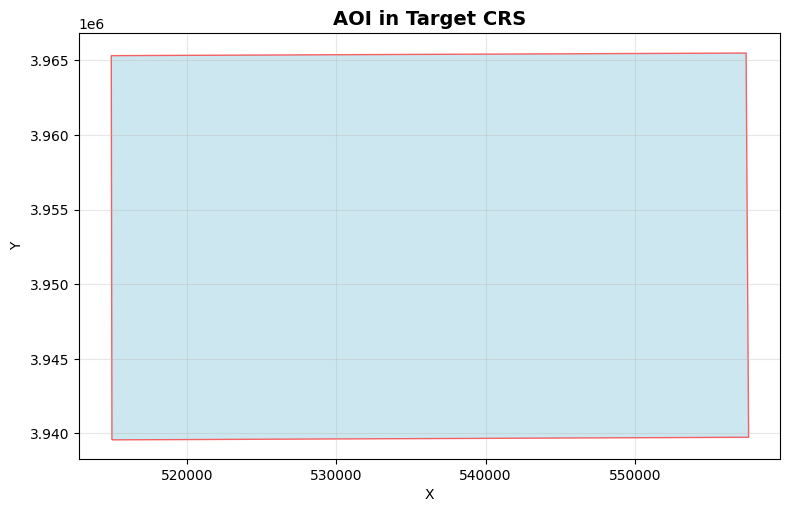

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
aoi_in_target_crs.plot(ax=ax, facecolor="lightblue", edgecolor="red", alpha=0.6)
ax.set_title("AOI in Target CRS", fontsize=14, fontweight="bold")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print("🔄 Preparing POST coherence rasters...")

post_results = []

for idx, raster_path in enumerate(post_files, start=1):
    output_name = make_output_name(raster_path, prefix="post")
    output_path = prepared_post_dir / output_name

    print(f"\n   [{idx}/{len(post_files)}] Processing POST raster:")
    print(f"      Input:  {raster_path.name}")
    print(f"      Output: {output_name}")

    result = prepare_single_raster(
        input_path=raster_path,
        output_path=output_path,
        aoi_gdf=aoi_gdf,
        target_profile=target_profile,
        resampling=resampling_method
    )
    result["group"] = "post"
    post_results.append(result)

    print(f"      ✅ Done")
    print(f"      Valid pixels: {result['valid_pixels']:,} / {result['total_pixels']:,} ({result['valid_percent']}%)")

print("\n✅ All POST rasters prepared successfully")

🔄 Preparing POST coherence rasters...

   [1/25] Processing POST raster:
      Input:  S1AA_20250212T023717_20260408T023707_VVR420_INT40_G_ueF_3546_corr.tif
      Output: post_S1AA_20250212T023717_20260408T023707_VVR420_INT40_G_ueF_3546_corr.tif
      ✅ Done
      Valid pixels: 693,781 / 693,781 (100.0%)

   [2/25] Processing POST raster:
      Input:  S1AA_20250224T023717_20260408T023707_VVR408_INT40_G_ueF_08BC_corr.tif
      Output: post_S1AA_20250224T023717_20260408T023707_VVR408_INT40_G_ueF_08BC_corr.tif
      ✅ Done
      Valid pixels: 693,781 / 693,781 (100.0%)

   [3/25] Processing POST raster:
      Input:  S1AA_20250308T023717_20260408T023707_VVR396_INT40_G_ueF_061D_corr.tif
      Output: post_S1AA_20250308T023717_20260408T023707_VVR396_INT40_G_ueF_061D_corr.tif
      ✅ Done
      Valid pixels: 693,781 / 693,781 (100.0%)

   [4/25] Processing POST raster:
      Input:  S1AA_20250320T023719_20260408T023707_VVR384_INT40_G_ueF_F4A1_corr.tif
      Output: post_S1AA_20250320T023719

In [10]:
print("🔄 Preparing BASELINE coherence rasters...")

baseline_results = []

for idx, raster_path in enumerate(baseline_files, start=1):
    output_name = make_output_name(raster_path, prefix="baseline")
    output_path = prepared_baseline_dir / output_name

    print(f"\n   [{idx}/{len(baseline_files)}] Processing BASELINE raster:")
    print(f"      Input:  {raster_path.name}")
    print(f"      Output: {output_name}")

    result = prepare_single_raster(
        input_path=raster_path,
        output_path=output_path,
        aoi_gdf=aoi_gdf,
        target_profile=target_profile,
        resampling=resampling_method
    )
    result["group"] = "baseline"
    baseline_results.append(result)

    print(f"      ✅ Done")
    print(f"      Valid pixels: {result['valid_pixels']:,} / {result['total_pixels']:,} ({result['valid_percent']}%)")

print("\n✅ All BASELINE rasters prepared successfully")

🔄 Preparing BASELINE coherence rasters...

   [1/24] Processing BASELINE raster:
      Input:  S1AA_20240206T023724_20250320T023719_VVP408_INT40_G_ueF_6CA2_corr.tif
      Output: baseline_S1AA_20240206T023724_20250320T023719_VVP408_INT40_G_ueF_6CA2_corr.tif
      ✅ Done
      Valid pixels: 693,781 / 693,781 (100.0%)

   [2/24] Processing BASELINE raster:
      Input:  S1AA_20240218T023724_20250320T023719_VVP396_INT40_G_ueF_05EA_corr.tif
      Output: baseline_S1AA_20240218T023724_20250320T023719_VVP396_INT40_G_ueF_05EA_corr.tif
      ✅ Done
      Valid pixels: 693,781 / 693,781 (100.0%)

   [3/24] Processing BASELINE raster:
      Input:  S1AA_20240301T023724_20250320T023719_VVP384_INT40_G_ueF_91D1_corr.tif
      Output: baseline_S1AA_20240301T023724_20250320T023719_VVP384_INT40_G_ueF_91D1_corr.tif
      ✅ Done
      Valid pixels: 693,781 / 693,781 (100.0%)

   [4/24] Processing BASELINE raster:
      Input:  S1AA_20240313T023724_20250320T023719_VVP372_INT40_G_ueF_C022_corr.tif
      O

In [11]:
print("📦 Building prepared raster inventory...")

prepared_inventory = pd.DataFrame(post_results + baseline_results)

print(f"   ✅ Prepared inventory created")
print(f"   Total prepared rasters: {len(prepared_inventory)}")
print(f"   POST rasters: {np.sum(prepared_inventory['group'] == 'post')}")
print(f"   BASELINE rasters: {np.sum(prepared_inventory['group'] == 'baseline')}")

display(prepared_inventory.head(10))

📦 Building prepared raster inventory...
   ✅ Prepared inventory created
   Total prepared rasters: 49
   POST rasters: 25
   BASELINE rasters: 24


,input_name,output_name,input_path,output_path,valid_pixels,total_pixels,valid_percent,group
0,S1AA_20250212T023717_20260408T023707_VVR420_IN...,post_S1AA_20250212T023717_20260408T023707_VVR4...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
1,S1AA_20250224T023717_20260408T023707_VVR408_IN...,post_S1AA_20250224T023717_20260408T023707_VVR4...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
2,S1AA_20250308T023717_20260408T023707_VVR396_IN...,post_S1AA_20250308T023717_20260408T023707_VVR3...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
3,S1AA_20250320T023719_20260408T023707_VVR384_IN...,post_S1AA_20250320T023719_20260408T023707_VVR3...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
4,S1AA_20250401T023718_20260408T023707_VVR372_IN...,post_S1AA_20250401T023718_20260408T023707_VVR3...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
5,S1AA_20250413T023718_20260408T023707_VVR360_IN...,post_S1AA_20250413T023718_20260408T023707_VVR3...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
6,S1AA_20250425T023718_20260408T023707_VVR348_IN...,post_S1AA_20250425T023718_20260408T023707_VVR3...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
7,S1AA_20250507T023718_20260408T023707_VVR336_IN...,post_S1AA_20250507T023718_20260408T023707_VVR3...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
8,S1AA_20250519T023718_20260408T023707_VVR324_IN...,post_S1AA_20250519T023718_20260408T023707_VVR3...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post
9,S1AA_20250718T023715_20260408T023707_VVR264_IN...,post_S1AA_20250718T023715_20260408T023707_VVR2...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/...,/Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_...,693781,693781,100.0,post


In [12]:
print("🔍 Running quality checks...")

post_prepared_raw = list(prepared_post_dir.glob("*.tif"))
baseline_prepared_raw = list(prepared_baseline_dir.glob("*.tif"))

post_prepared_files, skipped_post = filter_valid_tifs(post_prepared_raw)
baseline_prepared_files, skipped_baseline = filter_valid_tifs(baseline_prepared_raw)

print("🔍 Filtering prepared rasters:")
print(f"   POST valid: {len(post_prepared_files)} | skipped: {len(skipped_post)}")
print(f"   BASELINE valid: {len(baseline_prepared_files)} | skipped: {len(skipped_baseline)}")

if len(skipped_post) > 0:
    print(f"   ⚠️ Skipped POST system files: {skipped_post[:3]}...")
if len(skipped_baseline) > 0:
    print(f"   ⚠️ Skipped BASELINE system files: {skipped_baseline[:3]}...")

if len(post_prepared_files) == 0 or len(baseline_prepared_files) == 0:
    raise ValueError("Prepared raster folders are empty after processing.")

sample_files = [post_prepared_files[0], baseline_prepared_files[0]]

for sample in sample_files:
    with rasterio.open(sample) as src:
        print(f"\n   File: {sample.name}")
        print(f"      CRS: {src.crs}")
        print(f"      Shape: ({src.height}, {src.width})")
        print(f"      Transform: {src.transform}")
        print(f"      Bounds: {src.bounds}")

print("\n✅ Quality check completed")

🔍 Running quality checks...
🔍 Filtering prepared rasters:
   POST valid: 25 | skipped: 25
   BASELINE valid: 24 | skipped: 24
   ⚠️ Skipped POST system files: ['._post_S1AA_20250212T023717_20260408T023707_VVR420_INT40_G_ueF_3546_corr.tif', '._post_S1AA_20250224T023717_20260408T023707_VVR408_INT40_G_ueF_08BC_corr.tif', '._post_S1AA_20250308T023717_20260408T023707_VVR396_INT40_G_ueF_061D_corr.tif']...
   ⚠️ Skipped BASELINE system files: ['._baseline_S1AA_20240206T023724_20250320T023719_VVP408_INT40_G_ueF_6CA2_corr.tif', '._baseline_S1AA_20240218T023724_20250320T023719_VVP396_INT40_G_ueF_05EA_corr.tif', '._baseline_S1AA_20240301T023724_20250320T023719_VVP384_INT40_G_ueF_91D1_corr.tif']...

   File: post_S1AA_20250212T023717_20260408T023707_VVR420_INT40_G_ueF_3546_corr.tif
      CRS: EPSG:32639
      Shape: (649, 1069)
      Transform: | 40.00, 0.00, 514860.00|
| 0.00,-40.00, 3965540.00|
| 0.00, 0.00, 1.00|
      Bounds: BoundingBox(left=514860.0, bottom=3939580.0, right=557620.0, top=396

🖼️ Visualizing sample prepared rasters...


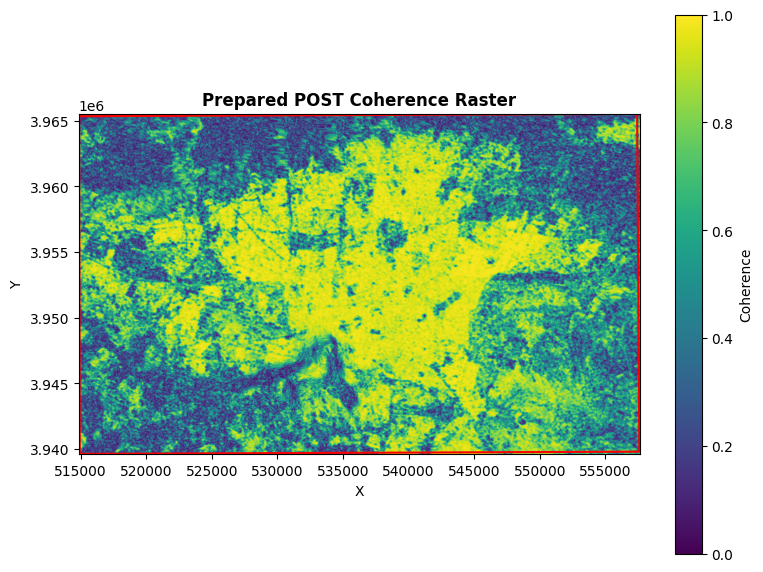

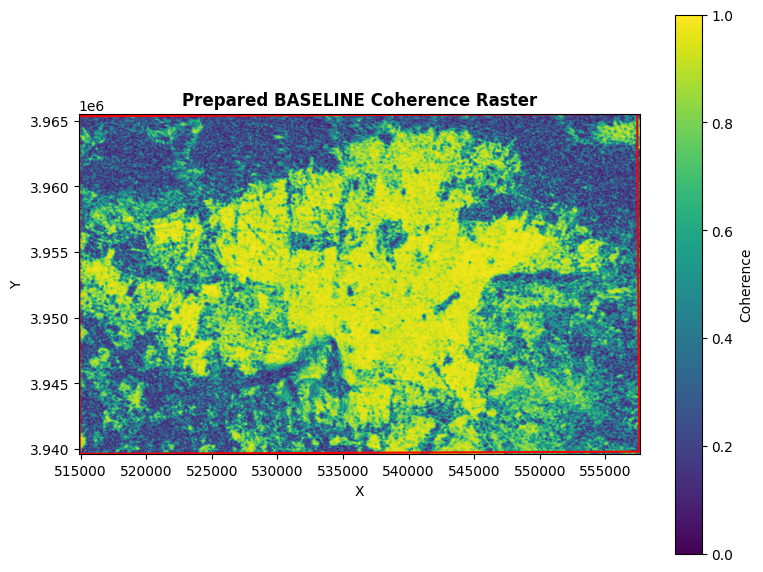

In [13]:
print("🖼️ Visualizing sample prepared rasters...")

preview_raster(post_prepared_files[0], aoi_gdf, "Prepared POST Coherence Raster")
preview_raster(baseline_prepared_files[0], aoi_gdf, "Prepared BASELINE Coherence Raster")

In [14]:
print("💾 Saving metadata and processing summary...")

inventory_csv_path = metadata_dir / "prepared_raster_inventory.csv"
inventory_json_path = metadata_dir / "prepared_raster_inventory.json"
summary_json_path = metadata_dir / "preparation_summary.json"

prepared_inventory.to_csv(inventory_csv_path, index=False)
prepared_inventory.to_json(inventory_json_path, orient="records", indent=2)

summary = {
    "processing_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "aoi_path": str(aoi_path),
    "post_input_dir": str(post_dir),
    "baseline_input_dir": str(baseline_dir),
    "output_root": str(output_root),
    "reference_source": reference_source,
    "reference_index": reference_index,
    "reference_raster": str(reference_raster),
    "target_crs": str(target_profile["crs"]),
    "target_width": int(target_profile["width"]),
    "target_height": int(target_profile["height"]),
    "target_transform": list(target_profile["transform"]),
    "n_post_input": len(post_files),
    "n_baseline_input": len(baseline_files),
    "n_post_prepared": int(np.sum(prepared_inventory["group"] == "post")),
    "n_baseline_prepared": int(np.sum(prepared_inventory["group"] == "baseline")),
    "prepared_post_dir": str(prepared_post_dir),
    "prepared_baseline_dir": str(prepared_baseline_dir)
}

with open(summary_json_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"   ✅ Inventory CSV saved: {inventory_csv_path}")
print(f"   ✅ Inventory JSON saved: {inventory_json_path}")
print(f"   ✅ Summary JSON saved: {summary_json_path}")

💾 Saving metadata and processing summary...
   ✅ Inventory CSV saved: /Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026/metadata/prepared_raster_inventory.csv
   ✅ Inventory JSON saved: /Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026/metadata/prepared_raster_inventory.json
   ✅ Summary JSON saved: /Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026/metadata/preparation_summary.json


In [15]:
print("🎉 LT-CCD data preparation completed successfully!")

print("\n📋 Final Summary:")
print(f"   AOI file: {aoi_path.name}")
print(f"   Reference raster: {reference_raster.name}")
print(f"   Target CRS: {target_profile['crs']}")
print(f"   Target shape: {target_profile['height']} x {target_profile['width']}")
print(f"   Prepared POST rasters: {len(post_results)}")
print(f"   Prepared BASELINE rasters: {len(baseline_results)}")

print("\n📁 Output folders:")
print(f"   POST prepared rasters: {prepared_post_dir}")
print(f"   BASELINE prepared rasters: {prepared_baseline_dir}")
print(f"   Metadata: {metadata_dir}")

print("\n🔄 Ready for Notebook 2: LT-CCD stack statistics and damage detection")

🎉 LT-CCD data preparation completed successfully!

📋 Final Summary:
   AOI file: Teheran_AOI.geojson
   Reference raster: S1AA_20250212T023717_20260408T023707_VVR420_INT40_G_ueF_3546_corr.tif
   Target CRS: EPSG:32639
   Target shape: 649 x 1069
   Prepared POST rasters: 25
   Prepared BASELINE rasters: 24

📁 Output folders:
   POST prepared rasters: /Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026/prepared/post
   BASELINE prepared rasters: /Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026/prepared/baseline
   Metadata: /Volumes/ChaikaT7/LT_CCD_damage/Data/Prepared_data/SLC_1/Prepared_08042026/metadata

🔄 Ready for Notebook 2: LT-CCD stack statistics and damage detection
